In [1]:
from pathlib import Path
OUTPUT_DIR = Path('/Users/fteodoro/Dropbox/Doutorado/Tese/figuras')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

rng = np.random.default_rng(42)
N   = 1000
y_true = rng.integers(0, 2, size=N)

In [3]:
# --- Synthetic ROC curves ---

# 1. Perfect classifier (AUC = 1.0)
#    scores = true label (no noise)
scores_perfect = y_true.astype(float)
fpr_perf, tpr_perf, _ = roc_curve(y_true, scores_perfect)
auc_perf = auc(fpr_perf, tpr_perf)

# 2. Good classifier (AUC ≈ 0.75)
#    scores = mix of signal and noise
scores_good = y_true * 0.7 + rng.normal(0, 0.45, size=N)
fpr_good, tpr_good, _ = roc_curve(y_true, scores_good)
auc_good = auc(fpr_good, tpr_good)

# 3. Random classifier (AUC ≈ 0.5, diagonal)
fpr_rand = np.linspace(0, 1, 100)
tpr_rand = fpr_rand.copy()
auc_rand = 0.5

print(f'AUC perfeito : {auc_perf:.3f}')
print(f'AUC bom      : {auc_good:.3f}')
print(f'AUC aleatório: {auc_rand:.3f}')

AUC perfeito : 1.000
AUC bom      : 0.877
AUC aleatório: 0.500


Saved: /Users/fteodoro/Dropbox/Doutorado/Tese/figuras/fig_roc_curve.pdf


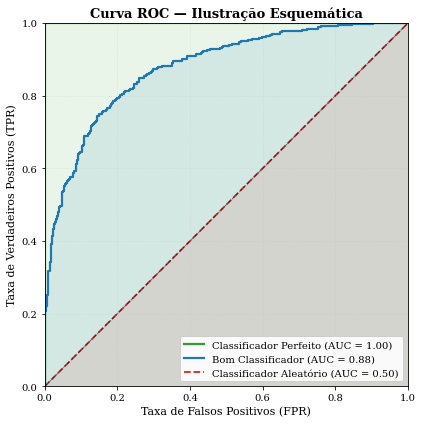

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

# Perfect
ax.plot(fpr_perf, tpr_perf, color='#2ca02c', lw=2.2,
        label=f'Classificador Perfeito (AUC = {auc_perf:.2f})')
ax.fill_between(fpr_perf, tpr_perf, alpha=0.10, color='#2ca02c')

# Good
ax.plot(fpr_good, tpr_good, color='#1f77b4', lw=2.2,
        label=f'Bom Classificador (AUC = {auc_good:.2f})')
ax.fill_between(fpr_good, tpr_good, alpha=0.10, color='#1f77b4')

# Random
ax.plot(fpr_rand, tpr_rand, color='#d62728', lw=1.8, ls='--',
        label=f'Classificador Aleatório (AUC = {auc_rand:.2f})')
ax.fill_between(fpr_rand, tpr_rand, alpha=0.10, color='#d62728')

# Diagonal reference
ax.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.5)

ax.set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC — Ilustração Esquemática', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.grid(alpha=0.3, ls=':')

fig.tight_layout()
out_path = OUTPUT_DIR / 'fig_roc_curve.pdf'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()